In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('Dataset/cardiovascular_disease.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df['age'] = df['age']//365

In [5]:
data = df[(df['height'].between(150, 200)) & (df['weight'].between(45, 120)) & (df['ap_hi'].between(100, 200)) & (df['ap_lo'].between(50, 90))]

In [6]:
data = data.drop(columns='id')

In [7]:
data_sample = data.sample(n=5000, random_state=42)
data_sample

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
25963,58,2,171,71.0,120,80,1,1,0,0,1,1
63554,57,1,150,96.0,120,85,1,2,0,0,0,1
61131,58,2,169,68.0,135,89,1,1,1,0,1,0
63639,57,2,176,84.0,120,80,2,2,0,0,1,1
18529,47,2,174,69.0,100,70,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
29285,62,1,161,82.0,120,80,1,2,1,0,1,1
627,41,2,178,103.0,120,80,1,1,0,0,1,0
10639,61,2,178,80.0,130,80,3,1,0,0,1,1
53377,41,2,171,107.0,130,79,1,1,0,0,1,1


In [8]:
feature = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
           'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [9]:
X = data_sample[feature]
Y = data_sample[target]

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [11]:
scaler = StandardScaler()

In [12]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [13]:
model = SVC(kernel='linear', gamma='scale', C=1, class_weight='balanced')

In [14]:
model.fit(X_train_scale, Y_train)
SVC(C=1, class_weight='balanced', kernel='linear')


,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [15]:
Y_pred = model.predict(X_test_scale)

In [16]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [17]:
print(cr)

              precision    recall  f1-score   support

           0       0.70      0.81      0.75       527
           1       0.74      0.62      0.67       473

    accuracy                           0.72      1000
   macro avg       0.72      0.71      0.71      1000
weighted avg       0.72      0.72      0.71      1000



In [18]:
print(cm)

[[427 100]
 [182 291]]


Text(0.5, 1.0, 'Cardiovascular Disease Prediction: Confusion Matrix')

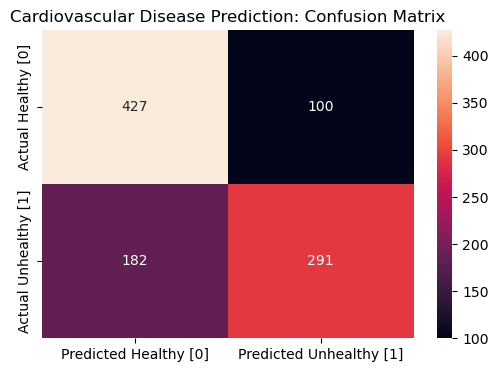

In [19]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='.0f', xticklabels=['Predicted Healthy [0]','Predicted Unhealthy [1]'],
           yticklabels=['Actual Healthy [0]', 'Actual Unhealthy [1]'])
plt.title('Cardiovascular Disease Prediction: Confusion Matrix')

In [20]:

# New patient data
data = {
    'age': [40, 30, 50],
    'gender': [1, 2, 1],
    'height': [160, 155, 170],
    'weight': [50, 60, 77],
    'ap_hi': [120, 170, 130],
    'ap_lo': [60, 80, 80],
    'cholesterol': [1, 1, 3],
    'gluc': [1, 1, 1],
    'smoke': [0, 1, 1],
    'alco': [1, 1, 0],
    'active': [1, 1, 0]
}

# Create a DataFrame
X_data = pd.DataFrame(data)
# Scale the data using the same scaler used during training
X_data_scale = scaler.transform(X_data)

# Predict cardiovascular disease
Y_new_pred = model.predict(X_data_scale)

# Add predictions to the DataFrame
X_data['predicted_cardio'] = Y_new_pred

# Display the results
print(X_data)

   age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0   40       1     160      50    120     60            1     1      0     1   
1   30       2     155      60    170     80            1     1      1     1   
2   50       1     170      77    130     80            3     1      1     0   

   active  predicted_cardio  
0       1                 0  
1       1                 1  
2       0                 1  
